In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

import statsmodels.api as sm
from sklearn.model_selection import cross_val_score, KFold

In [2]:
root = "data"
lung = pd.read_csv(f"{root}/LungDisease.csv")

In [11]:
%matplotlib inline

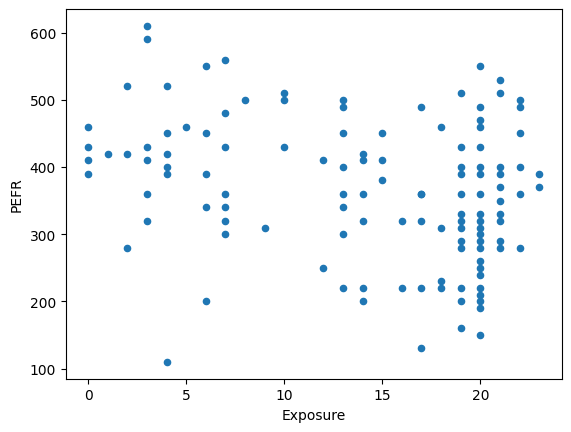

<Figure size 200x100 with 0 Axes>

In [3]:
lung.plot.scatter(x="Exposure", y="PEFR")


# plt.tight_layout()
plt.figure(figsize=(2,1), layout="constrained")
plt.show()

In [3]:
predictors = ["Exposure"]
target = "PEFR" 

model = LinearRegression()
model.fit(lung[predictors], lung[target])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
print(f'Intercept: {model.intercept_:.3f}')
print(f'Coefficient Exposure: {model.coef_[0]:.3f}')

Intercept: 424.583
Coefficient Exposure: -4.185


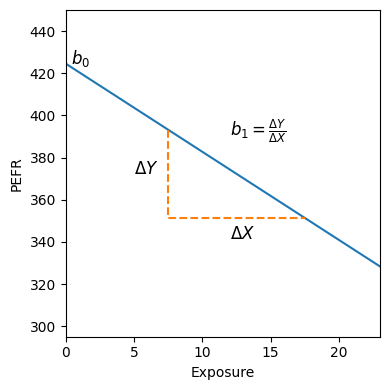

In [25]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(0, 23)
ax.set_ylim(295, 450)
ax.set_xlabel('Exposure')
ax.set_ylabel('PEFR')
ax.plot((0, 23), model.predict(pd.DataFrame({'Exposure': [0, 23]})))
ax.text(0.4, model.intercept_, r'$b_0$', size='larger')

x = pd.DataFrame({'Exposure': [7.5,17.5]})
y = model.predict(x)
ax.plot((7.5, 7.5, 17.5), (y[0], y[1], y[1]), '--')
ax.text(5, np.mean(y), r'$\Delta Y$', size='larger')
ax.text(12, y[1] - 10, r'$\Delta X$', size='larger')
ax.text(12, 390, r'$b_1 = \frac{\Delta Y}{\Delta X}$', size='larger')

plt.tight_layout()
plt.show()

In [7]:
fitted = model.predict(lung[predictors])

In [8]:
residuals = lung[target] - fitted

C:\Users\USER\Desktop\Dev Space\ML\playground\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


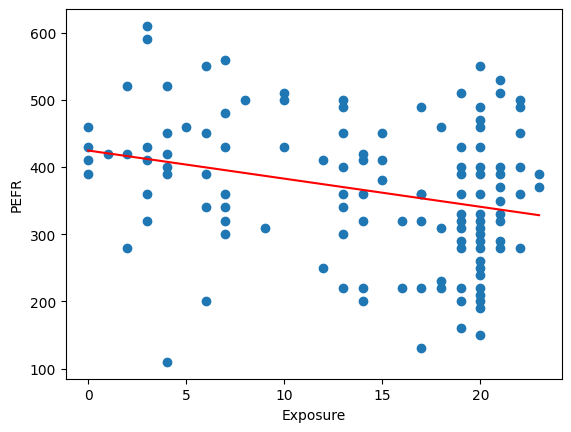

In [8]:
# scatter plot
plt.scatter(lung["Exposure"], lung["PEFR"])

# create x values across the range
x_vals = np.linspace(lung["Exposure"].min(), lung["Exposure"].max(), 100)
#x_vals = lung[predictors] 

# predict y values
y_vals = model.predict(x_vals.reshape(-1,len(predictors)))
# y_vals = model.predict(x_vals)

# plot fitted line
plt.plot(x_vals, y_vals, color="red")

plt.xlabel("Exposure")
plt.ylabel("PEFR")

plt.show()

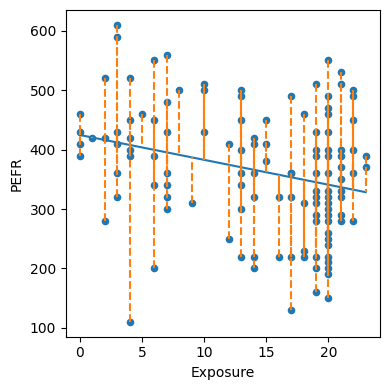

In [74]:
ax = lung.plot.scatter(x='Exposure', y='PEFR', figsize=(4, 4))
ax.plot(lung.Exposure, fitted)
for x, yactual, yfitted in zip(lung.Exposure, lung.PEFR, fitted): 
    ax.plot((x, x), (yactual, yfitted), '--', color='C1')

plt.tight_layout()
plt.show()

In [9]:
# Assessing the model
RMSE = np.sqrt(mean_squared_error(lung[target], fitted))
r2 = r2_score(lung[target], fitted)

In [10]:
print(f'RMSE: {RMSE:.0f}')
print(f'r2: {r2:.4f}')

RMSE: 101
r2: 0.0767


In [15]:
lung[target].min()

np.int64(110)

In [16]:
lung[target].max()

np.int64(610)

In [19]:
model = sm.OLS(lung[target], lung[predictors].assign(const=1))
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   PEFR   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     9.974
Date:                Sun, 15 Mar 2026   Prob (F-statistic):            0.00201
Time:                        15:08:41   Log-Likelihood:                -735.68
No. Observations:                 122   AIC:                             1475.
Df Residuals:                     120   BIC:                             1481.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Exposure      -4.1846      1.325     -3.158      0.0

In [20]:
np.std(lung[target])  
# RMSE ≈ std dev → your model isn't adding much over just predicting the mean
# RMSE << std dev → the model is genuinely learning something

# A small RMSE should never be read in isolation. R² puts it in context — and 
# a low R² is the more honest signal that the model isn't explaining 
# the data well, regardless of how small the absolute error looks.

# A model isn't good or bad in a vacuum — it's good or bad relative to the cost of being wrong
# in your specific use case. Always define what an acceptable error looks like before you train, not after.

np.float64(104.70088311993904)

In [11]:
# cross validation 
scores = cross_val_score(model, lung[predictors], lung[target], cv=5, scoring="r2")

print(scores)
print("Mean R2:", scores.mean())

[ 0.01503928  0.05017847 -0.24193125 -0.40990345 -2.37226828]
Mean R2: -0.5917770457291152


In [13]:
# cross validation 
scores = cross_val_score(model, lung[predictors], lung[target], cv=5, scoring="neg_root_mean_squared_error")

rmse = -scores
print(rmse)
print("Mean RMSE:", rmse.mean())

[103.80572166 102.84262109 108.13875404  98.02366472 143.25995257]
Mean RMSE: 111.21414281759958


In [ ]:
# manual cross validation

kf = KFold(n_split=5, shuffle=True, random_state=1)
scores = []

x = lung[predictors]
y = lung[target]

for train_idx, test_idx in kf.split(x):
    x_train, x_test = 

In [2]:
df.shape

NameError: name 'df' is not defined